In [2]:
from pathlib import Path

# 🔧 Flip this flag depending on where you're running
ON_GPU = True   # set True on university GPU, False on your laptop

if ON_GPU:
    data_root = Path(r"/workspaces/cmp9137-advanced-machine-learning/CMP9137 Advanced Machine Learning/skin-app/data")   # GPU path
else:
    data_root = Path(r"F:\skin-app\data")   # Laptop path

print("Using data_root:", data_root)


Using data_root: /workspaces/cmp9137-advanced-machine-learning/CMP9137 Advanced Machine Learning/skin-app/data


In [3]:
from pathlib import Path

# Root where you copied your data on the GPU
data_root = Path("/workspaces/cmp9137-advanced-machine-learning/CMP9137 Advanced Machine Learning/skin-app/data")

print("Using data_root:", data_root)

# Image roots for each dataset (relative to data_root)
DATASET_ROOTS = {
    "fitzpatrick17k": data_root / "fitzpatrick17k-main" / "finalfitz17k",
    "dermnet":        data_root / "dermnet",
    "padufes":        data_root / "PAD-UFES",
}

print("\nDataset roots:")
for k, v in DATASET_ROOTS.items():
    print(f" - {k}: {v}")


Using data_root: /workspaces/cmp9137-advanced-machine-learning/CMP9137 Advanced Machine Learning/skin-app/data

Dataset roots:
 - fitzpatrick17k: /workspaces/cmp9137-advanced-machine-learning/CMP9137 Advanced Machine Learning/skin-app/data/fitzpatrick17k-main/finalfitz17k
 - dermnet: /workspaces/cmp9137-advanced-machine-learning/CMP9137 Advanced Machine Learning/skin-app/data/dermnet
 - padufes: /workspaces/cmp9137-advanced-machine-learning/CMP9137 Advanced Machine Learning/skin-app/data/PAD-UFES


In [6]:
import pandas as pd
import os

train_path = data_root / "router_train.csv"
val_path   = data_root / "router_val.csv"

train_df = pd.read_csv(train_path)
val_df   = pd.read_csv(val_path)

def make_full_path(row):
    root = DATASET_ROOTS[row["dataset_name"]]
    return (root / row["image_relpath"]).as_posix()

train_df["full_path"] = train_df.apply(make_full_path, axis=1)
val_df["full_path"]   = val_df.apply(make_full_path, axis=1)

train_exists = train_df["full_path"].apply(os.path.exists).mean()
val_exists   = val_df["full_path"].apply(os.path.exists).mean()

print(f"Train file existence rate: {train_exists*100:.2f}%")
print(f"Val file existence rate:   {val_exists*100:.2f}%")

train_df.to_csv(train_path, index=False)
val_df.to_csv(val_path, index=False)


Train file existence rate: 100.00%
Val file existence rate:   100.00%


In [1]:
import pandas as pd
from pathlib import Path

# TODO: adjust this path if your file is elsewhere
meta_path = Path(r"F:\skin-app\data\fitzpatrick17k-main\fitzpatrick17k_metadata.csv")

df_fitz = pd.read_csv(meta_path)

print("Shape:", df_fitz.shape)
print("\nColumns:")
print(df_fitz.columns.tolist())

print("\nFirst 5 rows:")
df_fitz.head()


Shape: (16577, 9)

Columns:
['md5hash', 'fitzpatrick_scale', 'fitzpatrick_centaur', 'label', 'nine_partition_label', 'three_partition_label', 'qc', 'url', 'url_alphanum']

First 5 rows:


,md5hash,fitzpatrick_scale,fitzpatrick_centaur,label,nine_partition_label,three_partition_label,qc,url,url_alphanum
0,5e82a45bc5d78bd24ae9202d194423f8,3,3,drug induced pigmentary changes,inflammatory,non-neoplastic,NaN,https://www.dermaamin.com/site/images/clinical...,httpwwwdermaamincomsiteimagesclinicalpicmminoc...
1,fa2911a9b13b6f8af79cb700937cc14f,1,1,photodermatoses,inflammatory,non-neoplastic,NaN,https://www.dermaamin.com/site/images/clinical...,httpwwwdermaamincomsiteimagesclinicalpicpphoto...
2,d2bac3c9e4499032ca8e9b07c7d3bc40,2,3,dermatofibroma,benign dermal,benign,NaN,https://www.dermaamin.com/site/images/clinical...,httpwwwdermaamincomsiteimagesclinicalpicdderma...
3,0a94359e7eaacd7178e06b2823777789,1,1,psoriasis,inflammatory,non-neoplastic,NaN,https://www.dermaamin.com/site/images/clinical...,httpwwwdermaamincomsiteimagesclinicalpicppsori...
4,a39ec3b1f22c08a421fa20535e037bba,1,1,psoriasis,inflammatory,non-neoplastic,NaN,https://www.dermaamin.com/site/images/clinical...,httpwwwdermaamincomsiteimagesclinicalpicppsori...


In [2]:
# 1) How are cases grouped coarsely?
print("three_partition_label:")
print(df_fitz["three_partition_label"].value_counts())

print("\n\nnine_partition_label:")
print(df_fitz["nine_partition_label"].value_counts())

# 2) Peek at label + partition together
df_fitz[["label", "three_partition_label", "nine_partition_label"]].head(20)


three_partition_label:
three_partition_label
non-neoplastic    12080
malignant          2263
benign             2234
Name: count, dtype: int64


nine_partition_label:
nine_partition_label
inflammatory                    10886
malignant epidermal              1352
genodermatoses                   1194
benign dermal                    1067
benign epidermal                  931
malignant melanoma                573
benign melanocyte                 236
malignant cutaneous lymphoma      182
malignant dermal                  156
Name: count, dtype: int64


,label,three_partition_label,nine_partition_label
0,drug induced pigmentary changes,non-neoplastic,inflammatory
1,photodermatoses,non-neoplastic,inflammatory
2,dermatofibroma,benign,benign dermal
3,psoriasis,non-neoplastic,inflammatory
4,psoriasis,non-neoplastic,inflammatory
5,kaposi sarcoma,malignant,malignant dermal
6,neutrophilic dermatoses,non-neoplastic,inflammatory
7,granuloma annulare,non-neoplastic,inflammatory
8,nematode infection,non-neoplastic,inflammatory
9,allergic contact dermatitis,non-neoplastic,inflammatory


In [3]:
import pandas as pd
from pathlib import Path

# 1) Load metadata
meta_path = Path(r"F:\skin-app\data\fitzpatrick17k-main\fitzpatrick17k_metadata.csv")
df_fitz = pd.read_csv(meta_path)

print("Original shape:", df_fitz.shape)

# ⚠️ Do NOT filter on qc for now
# if "qc" in df_fitz.columns:
#     print("QC column values:", df_fitz["qc"].value_counts())

# 2) Map three_partition_label -> router_label
THREE_TO_ROUTER = {
    "benign": 0,          # lesion
    "malignant": 0,       # lesion
    "non-neoplastic": 1,  # rash
}

df_fitz["router_label"] = df_fitz["three_partition_label"].map(THREE_TO_ROUTER)

# Drop any rows we failed to map (should be none)
df_fitz = df_fitz.dropna(subset=["router_label"]).copy()
df_fitz["router_label"] = df_fitz["router_label"].astype(int)

# 3) Human-readable name
LABEL_ID_TO_NAME = {0: "lesion", 1: "rash"}
df_fitz["router_label_name"] = df_fitz["router_label"].map(LABEL_ID_TO_NAME)

# 4) Build relative image path from md5hash (adjust extension if needed)
df_fitz["image_relpath"] = df_fitz["md5hash"].astype(str) + ".jpg"

# 5) Keep only router-relevant columns
router_fitz = df_fitz[[
    "md5hash",
    "image_relpath",
    "label",
    "three_partition_label",
    "nine_partition_label",
    "router_label",
    "router_label_name",
    "fitzpatrick_scale",
]]

# 6) Save
out_path = Path(r"F:\skin-app\data\router_fitzpatrick.csv")
router_fitz.to_csv(out_path, index=False)

print("Saved:", out_path)
print("\nRouter label counts (Fitzpatrick only):")
print(router_fitz["router_label_name"].value_counts())

print("\nRouter label x Fitzpatrick scale:")
print(pd.crosstab(router_fitz["router_label_name"], router_fitz["fitzpatrick_scale"]))


Original shape: (16577, 9)
Saved: F:\skin-app\data\router_fitzpatrick.csv

Router label counts (Fitzpatrick only):
router_label_name
rash      12080
lesion     4497
Name: count, dtype: int64

Router label x Fitzpatrick scale:
fitzpatrick_scale   -1     1     2     3     4     5    6
router_label_name                                        
lesion             177   897  1413   931   668   306  105
rash               388  2050  3395  2377  2113  1227  530


In [4]:
import pandas as pd
from pathlib import Path

fitz_router_path = Path(r"F:\skin-app\data\fitzpatrick17k-main\fitzpatrick17k_metadata.csv")
router_fitz = pd.read_csv(fitz_router_path)

print("router_fitz shape:", router_fitz.shape)
print("\nColumns in router_fitz:")
print(router_fitz.columns.tolist())

print("\nFirst 3 rows:")
router_fitz.head(3)


router_fitz shape: (16577, 9)

Columns in router_fitz:
['md5hash', 'fitzpatrick_scale', 'fitzpatrick_centaur', 'label', 'nine_partition_label', 'three_partition_label', 'qc', 'url', 'url_alphanum']

First 3 rows:


,md5hash,fitzpatrick_scale,fitzpatrick_centaur,label,nine_partition_label,three_partition_label,qc,url,url_alphanum
0,5e82a45bc5d78bd24ae9202d194423f8,3,3,drug induced pigmentary changes,inflammatory,non-neoplastic,NaN,https://www.dermaamin.com/site/images/clinical...,httpwwwdermaamincomsiteimagesclinicalpicmminoc...
1,fa2911a9b13b6f8af79cb700937cc14f,1,1,photodermatoses,inflammatory,non-neoplastic,NaN,https://www.dermaamin.com/site/images/clinical...,httpwwwdermaamincomsiteimagesclinicalpicpphoto...
2,d2bac3c9e4499032ca8e9b07c7d3bc40,2,3,dermatofibroma,benign dermal,benign,NaN,https://www.dermaamin.com/site/images/clinical...,httpwwwdermaamincomsiteimagesclinicalpicdderma...


In [5]:
import pandas as pd
from pathlib import Path

# 1) Load original Fitzpatrick metadata
meta_path = Path(r"F:\skin-app\data\fitzpatrick17k-main\fitzpatrick17k_metadata.csv")
df_fitz = pd.read_csv(meta_path)

print("Original shape:", df_fitz.shape)

# 2) Map three_partition_label -> router_label (0=lesion, 1=rash)
THREE_TO_ROUTER = {
    "benign": 0,          # lesion
    "malignant": 0,       # lesion
    "non-neoplastic": 1,  # rash
}

df_fitz["router_label"] = df_fitz["three_partition_label"].map(THREE_TO_ROUTER)

# Drop any unmapped rows (should be none)
df_fitz = df_fitz.dropna(subset=["router_label"]).copy()
df_fitz["router_label"] = df_fitz["router_label"].astype(int)

# 3) Human-readable router label
LABEL_ID_TO_NAME = {0: "lesion", 1: "rash"}
df_fitz["router_label_name"] = df_fitz["router_label"].map(LABEL_ID_TO_NAME)

# 4) Build relative image path (adjust extension if needed)
df_fitz["image_relpath"] = df_fitz["md5hash"].astype(str) + ".jpg"

# 5) Add dataset_name column
df_fitz["dataset_name"] = "fitzpatrick17k"

# 6) Select and order columns for router_data
router_fitz = df_fitz[[
    "dataset_name",
    "md5hash",
    "image_relpath",
    "label",
    "three_partition_label",
    "nine_partition_label",
    "router_label",
    "router_label_name",
    "fitzpatrick_scale",
]]

# 7) Save as master router file (for now: only Fitzpatrick)
master_path = Path(r"F:\skin-app\data\router_data.csv")
router_fitz.to_csv(master_path, index=False)

print("Saved master router file at:", master_path)
print("\nRouter label counts (current master, Fitz only):")
print(router_fitz["router_label_name"].value_counts())


Original shape: (16577, 9)
Saved master router file at: F:\skin-app\data\router_data.csv

Router label counts (current master, Fitz only):
router_label_name
rash      12080
lesion     4497
Name: count, dtype: int64


In [6]:
from pathlib import Path

derm_root = Path(r"F:\skin-app\data\dermnet")  # <-- adjust if needed

top_dirs = [p for p in derm_root.iterdir() if p.is_dir()]
print("Top-level DermNet folders (first 50):")
for d in top_dirs[:50]:
    print("-", d.name)


Top-level DermNet folders (first 50):
- test
- train


In [7]:
from pathlib import Path

derm_root = Path(r"F:\skin-app\data\dermnet")  # adjust if needed

train_dir = derm_root / "train"
test_dir = derm_root / "test"

train_classes = sorted([p.name for p in train_dir.iterdir() if p.is_dir()])
test_classes = sorted([p.name for p in test_dir.iterdir() if p.is_dir()])

print("Number of train classes:", len(train_classes))
print("Train classes (first 50):")
for c in train_classes[:50]:
    print(" -", c)

print("\nNumber of test classes:", len(test_classes))
print("Test classes (first 50):")
for c in test_classes[:50]:
    print(" -", c)

# Sanity check: any classes only in train or only in test?
only_train = set(train_classes) - set(test_classes)
only_test = set(test_classes) - set(train_classes)

print("\nClasses only in train:", sorted(only_train))
print("Classes only in test:", sorted(only_test))


Number of train classes: 23
Train classes (first 50):
 - Acne and Rosacea Photos
 - Actinic Keratosis Basal Cell Carcinoma and other Malignant Lesions
 - Atopic Dermatitis Photos
 - Bullous Disease Photos
 - Cellulitis Impetigo and other Bacterial Infections
 - Eczema Photos
 - Exanthems and Drug Eruptions
 - Hair Loss Photos Alopecia and other Hair Diseases
 - Herpes HPV and other STDs Photos
 - Light Diseases and Disorders of Pigmentation
 - Lupus and other Connective Tissue diseases
 - Melanoma Skin Cancer Nevi and Moles
 - Nail Fungus and other Nail Disease
 - Poison Ivy Photos and other Contact Dermatitis
 - Psoriasis pictures Lichen Planus and related diseases
 - Scabies Lyme Disease and other Infestations and Bites
 - Seborrheic Keratoses and other Benign Tumors
 - Systemic Disease
 - Tinea Ringworm Candidiasis and other Fungal Infections
 - Urticaria Hives
 - Vascular Tumors
 - Vasculitis Photos
 - Warts Molluscum and other Viral Infections

Number of test classes: 23
Test clas

In [8]:
import pandas as pd
from pathlib import Path

# 1) Paths
master_path = Path(r"F:\skin-app\data\router_data.csv")   # master (currently Fitzpatrick only)
derm_root = Path(r"F:\skin-app\data\dermnet")             # your DermNet root

# 2) Load current master
router_master = pd.read_csv(master_path)
print("Current master shape (before DermNet):", router_master.shape)

# 3) Define SAFE rash folders (exact names from your listing)
SAFE_RASH_FOLDERS = {
    "Acne and Rosacea Photos",
    "Atopic Dermatitis Photos",
    "Bullous Disease Photos",
    "Cellulitis Impetigo and other Bacterial Infections",
    "Eczema Photos",
    "Exanthems and Drug Eruptions",
    "Herpes HPV and other STDs Photos",
    "Poison Ivy Photos and other Contact Dermatitis",
    "Psoriasis pictures Lichen Planus and related diseases",
    "Scabies Lyme Disease and other Infestations and Bites",
    "Tinea Ringworm Candidiasis and other Fungal Infections",
    "Urticaria Hives",
    "Vasculitis Photos",
    "Warts Molluscum and other Viral Infections",
}

valid_exts = {".jpg", ".jpeg", ".png", ".bmp"}
image_records = []

# 4) Loop over both train and test splits
for split in ["train", "test"]:
    split_dir = derm_root / split
    if not split_dir.exists():
        print(f"⚠️ Split folder missing: {split_dir}")
        continue

    for class_dir in split_dir.iterdir():
        if not class_dir.is_dir():
            continue

        class_name = class_dir.name

        # Only keep SAFE rash folders
        if class_name not in SAFE_RASH_FOLDERS:
            continue

        # Collect images from this class folder
        for img_path in class_dir.rglob("*"):
            if img_path.suffix.lower() in valid_exts:
                relpath = img_path.relative_to(derm_root).as_posix()

                image_records.append({
                    "dataset_name": "dermnet",
                    "md5hash": img_path.stem,
                    "image_relpath": relpath,
                    "label": class_name,
                    "three_partition_label": None,
                    "nine_partition_label": None,
                    "router_label": 1,          # rash
                    "router_label_name": "rash",
                    "fitzpatrick_scale": -1,    # unknown
                })

print("Found SAFE DermNet rash images:", len(image_records))

router_derm = pd.DataFrame(image_records)

if not router_derm.empty:
    # Align columns with master
    router_derm = router_derm[router_master.columns]

    # Append and save
    router_master_updated = pd.concat([router_master, router_derm], ignore_index=True)
    router_master_updated.to_csv(master_path, index=False)

    print("Updated master saved at:", master_path)
    print("New master shape:", router_master_updated.shape)

    print("\nRouter label counts (after adding DermNet rash):")
    print(router_master_updated["router_label_name"].value_counts())
else:
    print("⚠️ No SAFE DermNet rash images found. Check derm_root or SAFE_RASH_FOLDERS.")


Current master shape (before DermNet): (16577, 9)
Found SAFE DermNet rash images: 11632
Updated master saved at: F:\skin-app\data\router_data.csv
New master shape: (28209, 9)

Router label counts (after adding DermNet rash):
router_label_name
rash      23712
lesion     4497
Name: count, dtype: int64


In [9]:
import pandas as pd
from pathlib import Path

pad_meta_path = Path(r"F:\skin-app\data\PAD-UFES\metadata.csv")  # 🔁 ADJUST THIS

df_pad = pd.read_csv(pad_meta_path)

print("PAD-UFES shape:", df_pad.shape)
print("\nColumns:")
print(df_pad.columns.tolist())

print("\nFirst 5 rows:")
df_pad.head()


PAD-UFES shape: (2298, 26)

Columns:
['patient_id', 'lesion_id', 'smoke', 'drink', 'background_father', 'background_mother', 'age', 'pesticide', 'gender', 'skin_cancer_history', 'cancer_history', 'has_piped_water', 'has_sewage_system', 'fitspatrick', 'region', 'diameter_1', 'diameter_2', 'diagnostic', 'itch', 'grew', 'hurt', 'changed', 'bleed', 'elevation', 'img_id', 'biopsed']

First 5 rows:


,patient_id,lesion_id,smoke,drink,background_father,background_mother,age,pesticide,gender,skin_cancer_history,...,diameter_2,diagnostic,itch,grew,hurt,changed,bleed,elevation,img_id,biopsed
0,PAT_1516,1765,NaN,NaN,NaN,NaN,8,NaN,NaN,NaN,...,NaN,NEV,FALSE,FALSE,FALSE,FALSE,FALSE,FALSE,PAT_1516_1765_530.png,False
1,PAT_46,881,False,False,POMERANIA,POMERANIA,55,False,FEMALE,True,...,5.0,BCC,TRUE,TRUE,FALSE,TRUE,TRUE,TRUE,PAT_46_881_939.png,True
2,PAT_1545,1867,NaN,NaN,NaN,NaN,77,NaN,NaN,NaN,...,NaN,ACK,TRUE,FALSE,FALSE,FALSE,FALSE,FALSE,PAT_1545_1867_547.png,False
3,PAT_1989,4061,NaN,NaN,NaN,NaN,75,NaN,NaN,NaN,...,NaN,ACK,TRUE,FALSE,FALSE,FALSE,FALSE,FALSE,PAT_1989_4061_934.png,False
4,PAT_684,1302,False,True,POMERANIA,POMERANIA,79,False,MALE,True,...,5.0,BCC,TRUE,TRUE,FALSE,FALSE,TRUE,TRUE,PAT_684_1302_588.png,True


In [10]:
# Continuing from df_pad
print("diagnostic value counts:")
print(df_pad["diagnostic"].value_counts())

print("\nbiopsed value counts (if relevant):")
print(df_pad["biopsed"].value_counts())


diagnostic value counts:
diagnostic
BCC    845
ACK    730
NEV    244
SEK    235
SCC    192
MEL     52
Name: count, dtype: int64

biopsed value counts (if relevant):
biopsed
True     1342
False     956
Name: count, dtype: int64


In [11]:
from pathlib import Path

pad_root = Path(r"F:\skin-app\data\PAD-UFES")  # 🔁 change if your PAD-UFES path is different

print("Contents of PAD-UFES root:")
for p in pad_root.iterdir():
    print(" -", p.name, "(dir)" if p.is_dir() else "(file)")


Contents of PAD-UFES root:
 - imgs_part_1 (dir)
 - imgs_part_2 (dir)
 - imgs_part_3 (dir)
 - metadata.csv (file)


In [12]:
import pandas as pd
from pathlib import Path

# 1) Paths
master_path = Path(r"F:\skin-app\data\router_data.csv")          # master with Fitz + DermNet
pad_root = Path(r"F:\skin-app\data\PAD-UFES")                 # PAD-UFES root
pad_meta_path = pad_root / "metadata.csv"

# 2) Load current master + PAD-UFES metadata
router_master = pd.read_csv(master_path)
df_pad = pd.read_csv(pad_meta_path)

print("Current master shape (before PAD-UFES):", router_master.shape)
print("PAD-UFES metadata shape:", df_pad.shape)

# 3) Build a map from img_id -> relative image path
valid_exts = {".jpg", ".jpeg", ".png", ".bmp"}
image_map = {}

for img_path in pad_root.rglob("*"):
    if img_path.suffix.lower() in valid_exts:
        relpath = img_path.relative_to(pad_root).as_posix()
        stem = img_path.stem  # this should match df_pad["img_id"]
        if stem in image_map:
            # Optional: warn about duplicates
            # print("Duplicate image_id:", stem, "->", image_map[stem], "and", relpath)
            pass
        image_map[stem] = relpath

print("Number of image files indexed in PAD-UFES:", len(image_map))

# 4) Attach image_relpath to PAD-UFES metadata
df_pad["image_relpath"] = df_pad["img_id"].map(image_map)

missing = df_pad["image_relpath"].isna().sum()
print("PAD-UFES rows with missing image path:", missing)

# Drop rows without images (ideally 0)
df_pad = df_pad.dropna(subset=["image_relpath"]).copy()

# 5) Build router rows for PAD-UFES (all are lesions for router)
router_pad = pd.DataFrame({
    "dataset_name": "padufes",
    "md5hash": df_pad["img_id"].astype(str),
    "image_relpath": df_pad["image_relpath"],
    "label": df_pad["diagnostic"],          # BCC / SCC / etc.
    "three_partition_label": None,          # not using PAD-UFES for this
    "nine_partition_label": None,
    "router_label": 0,                      # lesion
    "router_label_name": "lesion",
    "fitzpatrick_scale": -1,                # no Fitzpatrick labels here
})

print("router_pad shape (PAD-UFES rows to add):", router_pad.shape)

# 6) Align columns with master and append
router_pad = router_pad[router_master.columns]

router_master_updated = pd.concat([router_master, router_pad], ignore_index=True)
router_master_updated.to_csv(master_path, index=False)

print("Updated master saved at:", master_path)
print("New master shape (after PAD-UFES):", router_master_updated.shape)

print("\nRouter label counts (after adding PAD-UFES):")
print(router_master_updated["router_label_name"].value_counts())


Current master shape (before PAD-UFES): (28209, 9)
PAD-UFES metadata shape: (2298, 26)
Number of image files indexed in PAD-UFES: 2298
PAD-UFES rows with missing image path: 2298
router_pad shape (PAD-UFES rows to add): (0, 9)
Updated master saved at: F:\skin-app\data\router_data.csv
New master shape (after PAD-UFES): (28209, 9)

Router label counts (after adding PAD-UFES):
router_label_name
rash      23712
lesion     4497
Name: count, dtype: int64


In [13]:
from pathlib import Path
import pandas as pd

pad_root = Path(r"F:\skin-app\data\PAD-UFES")
pad_meta_path = pad_root / "metadata.csv"

df_pad = pd.read_csv(pad_meta_path)

print("First 10 img_id values:")
print(df_pad["img_id"].head(10).tolist())

# Now look at 10 example image paths
valid_exts = {".jpg", ".jpeg", ".png", ".bmp"}
example_files = []

for img_path in pad_root.rglob("*"):
    if img_path.suffix.lower() in valid_exts:
        example_files.append(img_path.relative_to(pad_root).as_posix())
        if len(example_files) >= 10:
            break

print("\nExample image files (relative paths):")
for p in example_files:
    print(" -", p)


First 10 img_id values:
['PAT_1516_1765_530.png', 'PAT_46_881_939.png', 'PAT_1545_1867_547.png', 'PAT_1989_4061_934.png', 'PAT_684_1302_588.png', 'PAT_1549_1882_230.png', 'PAT_778_1471_835.png', 'PAT_117_179_983.png', 'PAT_1995_4080_695.png', 'PAT_705_4015_413.png']

Example image files (relative paths):
 - imgs_part_1/imgs_part_1/PAT_100_393_595.png
 - imgs_part_1/imgs_part_1/PAT_100_393_898.png
 - imgs_part_1/imgs_part_1/PAT_101_1041_651.png
 - imgs_part_1/imgs_part_1/PAT_101_1041_658.png
 - imgs_part_1/imgs_part_1/PAT_101_1041_898.png
 - imgs_part_1/imgs_part_1/PAT_104_1754_276.png
 - imgs_part_1/imgs_part_1/PAT_104_1755_320.png
 - imgs_part_1/imgs_part_1/PAT_104_1756_151.png
 - imgs_part_1/imgs_part_1/PAT_106_158_249.png
 - imgs_part_1/imgs_part_1/PAT_106_158_270.png


In [14]:
import pandas as pd
from pathlib import Path

# 1) Known-correct paths
data_root = Path(r"F:\skin-app\data")
master_path = data_root / "router_data.csv"

pad_root = data_root / "PAD-UFES"
pad_meta_path = pad_root / "metadata.csv"   # <- from your working code

print("PAD-UFES metadata path:", pad_meta_path)

# 2) Load current master + PAD-UFES metadata
router_master = pd.read_csv(master_path)
df_pad = pd.read_csv(pad_meta_path)

print("\nCurrent master shape (before PAD-UFES):", router_master.shape)
print("PAD-UFES metadata shape:", df_pad.shape)

# 3) Build map from full filename (img_id, including extension) -> relative image path
valid_exts = {".jpg", ".jpeg", ".png", ".bmp"}
image_map = {}

for img_path in pad_root.rglob("*"):
    if img_path.suffix.lower() in valid_exts:
        relpath = img_path.relative_to(pad_root).as_posix()
        filename = img_path.name  # e.g. 'PAT_1516_1765_530.png'
        image_map[filename] = relpath

print("Number of image files indexed in PAD-UFES:", len(image_map))

# 4) Attach image_relpath using img_id (which already has .png)
df_pad["image_relpath"] = df_pad["img_id"].map(image_map)
missing = df_pad["image_relpath"].isna().sum()
print("PAD-UFES rows with missing image path:", missing)

# Drop rows without images (should be 0 ideally)
df_pad = df_pad.dropna(subset=["image_relpath"]).copy()

# 5) Build router rows (all lesions for the router)
router_pad = pd.DataFrame({
    "dataset_name": "padufes",
    "md5hash": df_pad["img_id"].astype(str),
    "image_relpath": df_pad["image_relpath"],
    "label": df_pad["diagnostic"],
    "three_partition_label": None,
    "nine_partition_label": None,
    "router_label": 0,                  # lesion
    "router_label_name": "lesion",
    "fitzpatrick_scale": -1,            # unknown
})

print("router_pad shape (PAD-UFES rows to add):", router_pad.shape)

# 6) Align columns and append
router_pad = router_pad[router_master.columns]

router_master_updated = pd.concat([router_master, router_pad], ignore_index=True)
router_master_updated.to_csv(master_path, index=False)

print("\nUpdated master saved at:", master_path)
print("New master shape (after PAD-UFES):", router_master_updated.shape)

print("\nRouter label counts (after adding PAD-UFES):")
print(router_master_updated["router_label_name"].value_counts())


PAD-UFES metadata path: F:\skin-app\data\PAD-UFES\metadata.csv

Current master shape (before PAD-UFES): (28209, 9)
PAD-UFES metadata shape: (2298, 26)
Number of image files indexed in PAD-UFES: 2298
PAD-UFES rows with missing image path: 0
router_pad shape (PAD-UFES rows to add): (2298, 9)

Updated master saved at: F:\skin-app\data\router_data.csv
New master shape (after PAD-UFES): (30507, 9)

Router label counts (after adding PAD-UFES):
router_label_name
rash      23712
lesion     6795
Name: count, dtype: int64


In [15]:
import pandas as pd
from pathlib import Path

master_path = Path(r"F:\skin-app\data\router_data.csv")
router_master = pd.read_csv(master_path)

print("Master shape:", router_master.shape)
print("\nColumns:", router_master.columns.tolist())

print("\nCounts per dataset:")
print(router_master["dataset_name"].value_counts())

print("\nRash vs lesion per dataset:")
print(pd.crosstab(router_master["dataset_name"], router_master["router_label_name"]))


Master shape: (30507, 9)

Columns: ['dataset_name', 'md5hash', 'image_relpath', 'label', 'three_partition_label', 'nine_partition_label', 'router_label', 'router_label_name', 'fitzpatrick_scale']

Counts per dataset:
dataset_name
fitzpatrick17k    16577
dermnet           11632
padufes            2298
Name: count, dtype: int64

Rash vs lesion per dataset:
router_label_name  lesion   rash
dataset_name                    
dermnet                 0  11632
fitzpatrick17k       4497  12080
padufes              2298      0


In [16]:
#Model-2_Router_Split.ipynb

import pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split

data_root = Path(r"F:\skin-app\data")
master_path = data_root / "router_data.csv"

# 1) Load master router table
df = pd.read_csv(master_path)
print("Full router_data shape:", df.shape)
print("Router label distribution (overall):")
print(df["router_label_name"].value_counts())

# 2) Stratified train/val split
train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["router_label"],   # 0 = lesion, 1 = rash
    random_state=42,
)

print("\nTrain shape:", train_df.shape)
print("Val shape:", val_df.shape)

print("\nTrain label distribution:")
print(train_df["router_label_name"].value_counts())

print("\nVal label distribution:")
print(val_df["router_label_name"].value_counts())

# 3) Save splits
train_path = data_root / "router_train.csv"
val_path = data_root / "router_val.csv"

train_df.to_csv(train_path, index=False)
val_df.to_csv(val_path, index=False)

print("\nSaved:")
print(" -", train_path)
print(" -", val_path)


Full router_data shape: (30507, 9)
Router label distribution (overall):
router_label_name
rash      23712
lesion     6795
Name: count, dtype: int64

Train shape: (24405, 9)
Val shape: (6102, 9)

Train label distribution:
router_label_name
rash      18969
lesion     5436
Name: count, dtype: int64

Val label distribution:
router_label_name
rash      4743
lesion    1359
Name: count, dtype: int64

Saved:
 - F:\skin-app\data\router_train.csv
 - F:\skin-app\data\router_val.csv


In [17]:
from pathlib import Path

data_root = Path(r"F:\skin-app\data")

# 🔧 ADJUST these three roots if needed so they point to the ACTUAL image folders:
DATASET_ROOTS = {
    "fitzpatrick17k": data_root / "fitzpatrick17k-main" / "finalfitz17k",  # e.g. where the .jpgs live
    "dermnet":        data_root / "dermnet",                          # we used this already
    "padufes":        data_root / "PAD-UFES",                         # imgs_part_* under here
}

print("Dataset roots:")
for k, v in DATASET_ROOTS.items():
    print(f" - {k}: {DATASET_ROOTS[k]}")


Dataset roots:
 - fitzpatrick17k: F:\skin-app\data\fitzpatrick17k-main\finalfitz17k
 - dermnet: F:\skin-app\data\dermnet
 - padufes: F:\skin-app\data\PAD-UFES


In [18]:
from pathlib import Path

data_root = Path(r"F:\skin-app\data")

DATASET_ROOTS = {
    "fitzpatrick17k": Path(r"F:\skin-app\data\fitzpatrick17k-main\finalfitz17k"),
    "dermnet":        data_root / "dermnet",
    "padufes":        data_root / "PAD-UFES",
}

print("Dataset roots:")
for k, v in DATASET_ROOTS.items():
    print(f" - {k}: {v}")


Dataset roots:
 - fitzpatrick17k: F:\skin-app\data\fitzpatrick17k-main\finalfitz17k
 - dermnet: F:\skin-app\data\dermnet
 - padufes: F:\skin-app\data\PAD-UFES


In [19]:
import pandas as pd
import os
from pathlib import Path

data_root = Path(r"F:\skin-app\data")
train_path = data_root / "router_train.csv"
val_path   = data_root / "router_val.csv"

train_df = pd.read_csv(train_path)
val_df   = pd.read_csv(val_path)

def make_full_path(row):
    root = DATASET_ROOTS[row["dataset_name"]]
    return (root / row["image_relpath"]).as_posix()

# 1) Recompute full_path for everyone (overwrite old values)
train_df["full_path"] = train_df.apply(make_full_path, axis=1)
val_df["full_path"]   = val_df.apply(make_full_path, axis=1)

# 2) Overall existence rate
train_exists = train_df["full_path"].apply(os.path.exists).mean()
val_exists   = val_df["full_path"].apply(os.path.exists).mean()

print(f"Train file existence rate (overall): {train_exists*100:.2f}%")
print(f"Val file existence rate (overall):   {val_exists*100:.2f}%")

# 3) Per-dataset existence check
def existence_rate_by_dataset(df, name):
    print(f"\n{name} existence by dataset:")
    for ds in df["dataset_name"].unique():
        subset = df[df["dataset_name"] == ds]
        rate = subset["full_path"].apply(os.path.exists).mean()
        print(f" - {ds}: {rate*100:.2f}% (n={len(subset)})")

existence_rate_by_dataset(train_df, "Train")
existence_rate_by_dataset(val_df, "Val")

# 4) Save updated CSVs
train_df.to_csv(train_path, index=False)
val_df.to_csv(val_path, index=False)

print("\nUpdated router_train.csv and router_val.csv with new full_path.")


Train file existence rate (overall): 100.00%
Val file existence rate (overall):   100.00%

Train existence by dataset:
 - dermnet: 100.00% (n=9320)
 - fitzpatrick17k: 100.00% (n=13260)
 - padufes: 100.00% (n=1825)

Val existence by dataset:
 - fitzpatrick17k: 100.00% (n=3317)
 - dermnet: 100.00% (n=2312)
 - padufes: 100.00% (n=473)

Updated router_train.csv and router_val.csv with new full_path.


In [7]:
import tensorflow as tf
import pandas as pd
from pathlib import Path

# -----------------
# Config
# -----------------
IMG_SIZE = (224, 224)
BATCH_SIZE = 32  # we can tune later

#data_root = Path(r"F:\skin-app\data")
train_path = data_root / "router_train.csv"
val_path   = data_root / "router_val.csv"

# -----------------
# Load CSVs
# -----------------
train_df = pd.read_csv(train_path)
val_df   = pd.read_csv(val_path)

print("Train shape:", train_df.shape)
print("Val shape:", val_df.shape)
print("\nTrain label distribution:")
print(train_df["router_label_name"].value_counts())
print("\nVal label distribution:")
print(val_df["router_label_name"].value_counts())

# Convert to numpy arrays for tf.data
train_paths  = train_df["full_path"].values
train_labels = train_df["router_label"].values  # 0 = lesion, 1 = rash

val_paths  = val_df["full_path"].values
val_labels = val_df["router_label"].values

# -----------------
# TF image loader
# -----------------
def parse_image(path, label):
    # path: scalar string tensor
    img = tf.io.read_file(path)
    img = tf.io.decode_jpeg(img, channels=3)  # works for PNG too
    img = tf.image.resize(img, IMG_SIZE)

    # Keep values in 0–255 range as float32
    img = tf.cast(img, tf.float32)

    label = tf.cast(label, tf.int32)
    return img, label

def make_dataset(paths, labels, training=True):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(parse_image, num_parallel_calls=tf.data.AUTOTUNE)

    if training:
        ds = ds.shuffle(4096, reshuffle_each_iteration=True)

    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_dataset(train_paths, train_labels, training=True)
val_ds   = make_dataset(val_paths, val_labels, training=False)

# -----------------
# Inspect one batch
# -----------------
for batch_imgs, batch_labels in train_ds.take(1):
    print("\nOne batch from train_ds:")
    print("  image batch shape:", batch_imgs.shape)
    print("  image dtype:", batch_imgs.dtype)
    print("  label batch shape:", batch_labels.shape)
    print("  label dtype:", batch_labels.dtype)


Train shape: (24405, 10)
Val shape: (6102, 10)

Train label distribution:
router_label_name
rash      18969
lesion     5436
Name: count, dtype: int64

Val label distribution:
router_label_name
rash      4743
lesion    1359
Name: count, dtype: int64


2025-12-01 03:20:17.492714: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 3234 of 4096
2025-12-01 03:20:20.342319: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:480] Shuffle buffer filled.



One batch from train_ds:
  image batch shape: (32, 224, 224, 3)
  image dtype: <dtype: 'float32'>
  label batch shape: (32,)
  label dtype: <dtype: 'int32'>


2025-12-01 03:20:20.665967: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [8]:
import tensorflow as tf
from tensorflow.keras.applications.mobilenet_v3 import preprocess_input

# Simple augmentation block (applied only on TRAIN batches)
data_augmentation = tf.keras.Sequential(
    [
        tf.keras.layers.RandomFlip("horizontal"),
        tf.keras.layers.RandomRotation(0.1),  # ~±10%
    ],
    name="data_augmentation",
)

def preprocess_batch(images, labels, training=False):
    """Apply augmentation (if training) + MobileNetV3 preprocess_input."""
    if training:
        images = data_augmentation(images)
    # images are currently 0–255 float32; preprocess_input will scale to [-1, 1]
    images = preprocess_input(images)
    return images, labels

# Wrap your existing train_ds / val_ds from before
train_ds_prep = train_ds.map(
    lambda x, y: preprocess_batch(x, y, training=True),
    num_parallel_calls=tf.data.AUTOTUNE,
)

val_ds_prep = val_ds.map(
    lambda x, y: preprocess_batch(x, y, training=False),
    num_parallel_calls=tf.data.AUTOTUNE,
)

train_ds_prep = train_ds_prep.prefetch(tf.data.AUTOTUNE)
val_ds_prep   = val_ds_prep.prefetch(tf.data.AUTOTUNE)

# Inspect one preprocessed batch
for batch_imgs, batch_labels in train_ds_prep.take(1):
    print("After preprocess:")
    print("  image batch shape:", batch_imgs.shape)
    print("  image dtype:", batch_imgs.dtype)
    print("  image min/max:", float(tf.reduce_min(batch_imgs)), float(tf.reduce_max(batch_imgs)))
    print("  labels shape:", batch_labels.shape)
    break


After preprocess:
  image batch shape: (32, 224, 224, 3)
  image dtype: <dtype: 'float32'>
  image min/max: 0.0 255.0
  labels shape: (32,)


In [9]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

# We already loaded train_df earlier
y_train = train_df["router_label"].values  # 0 = lesion, 1 = rash

classes = np.array([0, 1])
weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)

class_weights = {0: float(weights[0]), 1: float(weights[1])}

print("Class counts in train:")
print(train_df["router_label_name"].value_counts())
print("\nComputed class_weights (for Keras):")
print(class_weights)


Class counts in train:
router_label_name
rash      18969
lesion     5436
Name: count, dtype: int64

Computed class_weights (for Keras):
{0: 2.244757174392936, 1: 0.6432864146765775}


In [10]:
import tensorflow as tf

# Reuse your existing train_ds / val_ds from before (the ones that only parse images)
# train_ds: (img 0–255 float32, label)
# val_ds:   (img 0–255 float32, label)

# Augmentation block
data_augmentation = tf.keras.Sequential(
    [
        tf.keras.layers.RandomFlip("horizontal"),
        tf.keras.layers.RandomRotation(0.1),
    ],
    name="data_augmentation",
)

def augment_batch(images, labels):
    images = data_augmentation(images, training=True)
    return images, labels

# Apply augmentation ONLY to train
train_ds_aug = train_ds.map(
    augment_batch,
    num_parallel_calls=tf.data.AUTOTUNE,
).prefetch(tf.data.AUTOTUNE)

# Validation: no aug, just prefetch
val_ds_clean = val_ds.prefetch(tf.data.AUTOTUNE)

# Quick check
for imgs, labels in train_ds_aug.take(1):
    print("Augmented batch:")
    print("  image batch shape:", imgs.shape)
    print("  image dtype:", imgs.dtype)
    print("  image min/max:", float(tf.reduce_min(imgs)), float(tf.reduce_max(imgs)))
    print("  labels shape:", labels.shape)
    break


Augmented batch:
  image batch shape: (32, 224, 224, 3)
  image dtype: <dtype: 'float32'>
  image min/max: 0.0 255.0
  labels shape: (32,)


In [25]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV3Small

IMG_SIZE = (224, 224, 3)

# 1) Input: raw 0–255 images
inputs = layers.Input(shape=IMG_SIZE, name="image_input")

# ❌ NO manual Rescaling here. MobileNetV3 has its own rescaling as first layer.
# Just feed 0–255 directly into the backbone.

base_model = MobileNetV3Small(
    include_top=False,
    weights="imagenet",
    input_shape=IMG_SIZE,
    pooling="avg",
    name="mobilenetv3_backbone",
)

# 2) Freeze backbone for Stage 1
base_model.trainable = False

# Important: training=False so BN layers stay in inference mode while frozen
x = base_model(inputs, training=False)

# 3) Small classification head
x = layers.Dropout(0.2, name="dropout_head")(x)
outputs = layers.Dense(1, activation="sigmoid", name="router_output")(x)

router_model = models.Model(inputs=inputs, outputs=outputs, name="router_mnv3_router_fixed")

router_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=False),
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name="accuracy"),
        tf.keras.metrics.AUC(name="auc"),
    ],
)

router_model.summary(line_length=120)
print("\nBackbone trainable:", base_model.trainable)


Model: "router_mnv3_router_fixed"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━
┃ Layer (type)                                        ┃ Output Shape                           ┃               Para
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━
│ image_input (InputLayer)                            │ (None, 224, 224, 3)                    │                   
├─────────────────────────────────────────────────────┼────────────────────────────────────────┼───────────────────
│ mobilenetv3_backbone (Functional)                   │ (None, 576)                            │               939,
├─────────────────────────────────────────────────────┼────────────────────────────────────────┼───────────────────
│ dropout_head (Dropout)                              │ (None, 576)                            │                   
├─────────────────────────────────────────────────────┼────────────────────────────────────────┼───────────────────
│ router_output (Dense)                               │ (None, 1)                              │                   
└─────────────────────────────────────────────────────┴────────────────────────────────────────┴───────────────────

 Total params: 939,697 (3.58 MB)

 Trainable params: 577 (2.25 KB)

 Non-trainable params: 939,120 (3.58 MB)


Backbone trainable: False


In [26]:
import tensorflow as tf
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.utils.class_weight import compute_class_weight

data_root = Path(r"F:\skin-app\data")
train_path = data_root / "router_train.csv"

# 1) Reload train_df
train_df = pd.read_csv(train_path)

# 2) Compute class weights (0 = lesion, 1 = rash)
y_train = train_df["router_label"].values
classes = np.array([0, 1])
weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
class_weights = {0: float(weights[0]), 1: float(weights[1])}

print("Train class counts:")
print(train_df["router_label_name"].value_counts())
print("\nClass weights used in training:")
print(class_weights)

# 3) Callbacks (fast mode)
artifacts_dir = data_root / "artifacts"
artifacts_dir.mkdir(exist_ok=True)

checkpoint_path = artifacts_dir / "router_mnv3_stage1_fixed_fast.keras"

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_auc",
    mode="max",
    patience=2,
    restore_best_weights=True,
    verbose=1,
)

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath=str(checkpoint_path),
    monitor="val_auc",
    mode="max",
    save_best_only=True,
    verbose=1,
)

# 4) FAST training config
EPOCHS = 6
STEPS_PER_EPOCH = 200   # subset of train
VAL_STEPS = 60          # subset of val

history_stage1 = router_model.fit(
    train_ds_aug,
    epochs=EPOCHS,
    steps_per_epoch=STEPS_PER_EPOCH,
    validation_data=val_ds_clean,
    validation_steps=VAL_STEPS,
    class_weight=class_weights,
    callbacks=[early_stop, checkpoint],
)

print("\nBest Stage 1 model saved to:", checkpoint_path)
print("History keys:", history_stage1.history.keys())


Train class counts:
router_label_name
rash      18969
lesion     5436
Name: count, dtype: int64

Class weights used in training:
{0: 2.244757174392936, 1: 0.6432864146765775}
Epoch 1/6
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 924ms/step - accuracy: 0.6274 - auc: 0.5862 - loss: 0.7325
Epoch 1: val_auc improved from None to 0.71518, saving model to F:\skin-app\data\artifacts\router_mnv3_stage1_fixed_fast.keras
200/200 ━━━━━━━━━━━━━━━━━━━━ 310s 1s/step - accuracy: 0.6275 - auc: 0.6252 - loss: 0.6976 - val_accuracy: 0.6547 - val_auc: 0.7152 - val_loss: 0.6332
Epoch 2/6
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 990ms/step - accuracy: 0.6625 - auc: 0.6939 - loss: 0.6370
Epoch 2: val_auc improved from 0.71518 to 0.78884, saving model to F:\skin-app\data\artifacts\router_mnv3_stage1_fixed_fast.keras
200/200 ━━━━━━━━━━━━━━━━━━━━ 226s 1s/step - accuracy: 0.6913 - auc: 0.7321 - loss: 0.6065 - val_accuracy: 0.7255 - val_auc: 0.7888 - val_loss: 0.5629
Epoch 3/6
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 58s/step - accuracy: 0.7

d:\Python\Lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 4: val_auc improved from 0.81526 to 0.82538, saving model to F:\skin-app\data\artifacts\router_mnv3_stage1_fixed_fast.keras
200/200 ━━━━━━━━━━━━━━━━━━━━ 172s 861ms/step - accuracy: 0.7489 - auc: 0.7931 - loss: 0.5546 - val_accuracy: 0.7557 - val_auc: 0.8254 - val_loss: 0.5192
Epoch 5/6
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 994ms/step - accuracy: 0.7266 - auc: 0.7803 - loss: 0.5705
Epoch 5: val_auc improved from 0.82538 to 0.83652, saving model to F:\skin-app\data\artifacts\router_mnv3_stage1_fixed_fast.keras
200/200 ━━━━━━━━━━━━━━━━━━━━ 384s 1s/step - accuracy: 0.7344 - auc: 0.7938 - loss: 0.5522 - val_accuracy: 0.7885 - val_auc: 0.8365 - val_loss: 0.4802
Epoch 6/6
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7654 - auc: 0.8127 - loss: 0.5248
Epoch 6: val_auc improved from 0.83652 to 0.84242, saving model to F:\skin-app\data\artifacts\router_mnv3_stage1_fixed_fast.keras
200/200 ━━━━━━━━━━━━━━━━━━━━ 260s 1s/step - accuracy: 0.7623 - auc: 0.8103 - loss: 0.5268 - val_accuracy: 0

In [27]:
import tensorflow as tf

# Load the base model exactly as you did in training
base = tf.keras.applications.MobileNetV3Small(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

print("Layer 0:", base.layers[0].name)
print("Layer 1:", base.layers[1].name)
print("Layer 2:", base.layers[2].name)

# Check specific values
print("\nChecking GPU availability:")
print(tf.config.list_physical_devices('GPU'))

Layer 0: input_layer_4
Layer 1: rescaling_2
Layer 2: conv

Checking GPU availability:
[]


In [7]:
!pip install "numpy<2.0" --force-reinstall


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 49.1 MB/s  0:00:00 eta 0:00:01
  Attempting uninstall: numpy
    Found existing installation: numpy 2.2.6
    Uninstalling numpy-2.2.6:
      Successfully uninstalled numpy-2.2.6
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python3 -m pip install --upgrade pip


In [10]:
!pip install scikit-learn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 38.0 MB/s  0:00:00m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.9/35.9 MB 40.5 MB/s  0:00:00m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [scikit-learn] [scikit-learn]

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python3 -m pip install --upgrade pip


Training for GPU

In [5]:
import tensorflow as tf
import pandas as pd

BATCH_SIZE = 32
IMG_SIZE = (224, 224)

train_path = data_root / "router_train.csv"
val_path   = data_root / "router_val.csv"

train_df = pd.read_csv(train_path)
val_df   = pd.read_csv(val_path)

print("Train shape:", train_df.shape)
print("Val shape:", val_df.shape)
print("\nTrain label distribution:")
print(train_df["router_label_name"].value_counts())
print("\nVal label distribution:")
print(val_df["router_label_name"].value_counts())

train_paths  = train_df["full_path"].values
train_labels = train_df["router_label"].values  # 0=lesion, 1=rash

val_paths  = val_df["full_path"].values
val_labels = val_df["router_label"].values

def parse_image(path, label):
    img = tf.io.read_file(path)
    img = tf.io.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32)  # 0–255
    label = tf.cast(label, tf.int32)
    return img, label

def make_dataset(paths, labels, training=True):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(parse_image, num_parallel_calls=tf.data.AUTOTUNE)
    if training:
        ds = ds.shuffle(4096, reshuffle_each_iteration=True)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_dataset(train_paths, train_labels, training=True)
val_ds   = make_dataset(val_paths, val_labels, training=False)

# Augmentation only on train
data_augmentation = tf.keras.Sequential(
    [
        tf.keras.layers.RandomFlip("horizontal"),
        tf.keras.layers.RandomRotation(0.1),
    ],
    name="data_augmentation",
)

def augment_batch(images, labels):
    images = data_augmentation(images, training=True)
    return images, labels

train_ds_aug = train_ds.map(
    augment_batch,
    num_parallel_calls=tf.data.AUTOTUNE,
).prefetch(tf.data.AUTOTUNE)

val_ds_clean = val_ds.prefetch(tf.data.AUTOTUNE)

# Sanity check
for imgs, labels in train_ds_aug.take(1):
    print("\nAugmented batch:")
    print("  image batch shape:", imgs.shape)
    print("  image dtype:", imgs.dtype)
    print("  image min/max:", float(tf.reduce_min(imgs)), float(tf.reduce_max(imgs)))
    print("  labels shape:", labels.shape)
    break


Train shape: (24405, 10)
Val shape: (6102, 10)

Train label distribution:
router_label_name
rash      18969
lesion     5436
Name: count, dtype: int64

Val label distribution:
router_label_name
rash      4743
lesion    1359
Name: count, dtype: int64


I0000 00:00:1764555082.757221    9662 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1764555082.928891    9662 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1764555082.928955    9662 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1764555082.931893    9662 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1764555082.931925    9662 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:0


Augmented batch:
  image batch shape: (32, 224, 224, 3)
  image dtype: <dtype: 'float32'>
  image min/max: 0.0 255.0
  labels shape: (32,)


In [6]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV3Small

IMG_SIZE = (224, 224, 3)

# 1) Input: raw 0–255 images
inputs = layers.Input(shape=IMG_SIZE, name="image_input")

# 2) MobileNetV3 backbone (has its own internal rescaling)
base_model = MobileNetV3Small(
    include_top=False,
    weights="imagenet",
    input_shape=IMG_SIZE,
    pooling="avg",
    name="mobilenetv3_backbone",
)

# Stage 1: freeze backbone
base_model.trainable = False

# Important: training=False so BN stays in inference mode while frozen
x = base_model(inputs, training=False)

# 3) Small classification head
x = layers.Dropout(0.2, name="dropout_head")(x)
outputs = layers.Dense(1, activation="sigmoid", name="router_output")(x)

router_model = models.Model(inputs=inputs, outputs=outputs, name="router_mnv3_router")

router_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=False),
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name="accuracy"),
        tf.keras.metrics.AUC(name="auc"),
    ],
)

router_model.summary(line_length=120)
print("\nBackbone trainable:", base_model.trainable)


4334752/4334752 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "router_mnv3_router"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━
┃ Layer (type)                                        ┃ Output Shape                           ┃               Para
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━
│ image_input (InputLayer)                            │ (None, 224, 224, 3)                    │                   
├─────────────────────────────────────────────────────┼────────────────────────────────────────┼───────────────────
│ mobilenetv3_backbone (Functional)                   │ (None, 576)                            │               939,
├─────────────────────────────────────────────────────┼────────────────────────────────────────┼───────────────────
│ dropout_head (Dropout)                              │ (None, 576)                            │                   
├─────────────────────────────────────────────────────┼────────────────────────────────────────┼───────────────────
│ router_output (Dense)                               │ (None, 1)                              │                   
└─────────────────────────────────────────────────────┴────────────────────────────────────────┴───────────────────

 Total params: 939,697 (3.58 MB)

 Trainable params: 577 (2.25 KB)

 Non-trainable params: 939,120 (3.58 MB)


Backbone trainable: False


In [11]:
import tensorflow as tf
import pandas as pd
import numpy as np
from sklearn.utils.class_weight import compute_class_weight
from pathlib import Path

# 1) Reload train_df (just to be safe)
train_path = data_root / "router_train.csv"
train_df = pd.read_csv(train_path)

print("Train class counts:")
print(train_df["router_label_name"].value_counts())

# 2) Compute class weights: 0 = lesion, 1 = rash
y_train = train_df["router_label"].values
classes = np.array([0, 1])
weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
class_weights = {0: float(weights[0]), 1: float(weights[1])}

print("\nClass weights used in training:")
print(class_weights)

# 3) Callbacks
artifacts_dir = data_root / "artifacts"
artifacts_dir.mkdir(exist_ok=True)

checkpoint_path = artifacts_dir / "router_mnv3_stage1_gpu.keras"

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_auc",
    mode="max",
    patience=3,
    restore_best_weights=True,
    verbose=1,
)

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath=str(checkpoint_path),
    monitor="val_auc",
    mode="max",
    save_best_only=True,
    verbose=1,
)

# 4) Train Stage 1 (full dataset, GPU)
EPOCHS = 15

history_stage1 = router_model.fit(
    train_ds_aug,
    epochs=EPOCHS,
    validation_data=val_ds_clean,
    class_weight=class_weights,
    callbacks=[early_stop, checkpoint],
)

print("\nBest Stage 1 model saved to:", checkpoint_path)
print("History keys:", history_stage1.history.keys())


Train class counts:
router_label_name
rash      18969
lesion     5436
Name: count, dtype: int64

Class weights used in training:
{0: 2.244757174392936, 1: 0.6432864146765775}
Epoch 1/15


I0000 00:00:1764556186.447182   10015 service.cc:146] XLA service 0x779db0001e30 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1764556186.447462   10015 service.cc:154]   StreamExecutor device (0): NVIDIA GeForce RTX 3060, Compute Capability 8.6
2025-12-01 02:29:46.706640: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-12-01 02:29:48.999109: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 8906


  1/763 ━━━━━━━━━━━━━━━━━━━━ 5:42:19 27s/step - accuracy: 0.5000 - auc: 0.5000 - loss: 0.5695

I0000 00:00:1764556199.401914   10015 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


763/763 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - accuracy: 0.5482 - auc: 0.5022 - loss: 0.7789
Epoch 1: val_auc improved from -inf to 0.78267, saving model to /workspaces/cmp9137-advanced-machine-learning/CMP9137 Advanced Machine Learning/skin-app/data/artifacts/router_mnv3_stage1_gpu.keras
763/763 ━━━━━━━━━━━━━━━━━━━━ 149s 160ms/step - accuracy: 0.5483 - auc: 0.5024 - loss: 0.7788 - val_accuracy: 0.7035 - val_auc: 0.7827 - val_loss: 0.5758
Epoch 2/15


...

763/763 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.7985 - auc: 0.8687 - loss: 0.4519
Epoch 14: val_auc improved from 0.88355 to 0.88474, saving model to /workspaces/cmp9137-advanced-machine-learning/CMP9137 Advanced Machine Learning/skin-app/data/artifacts/router_mnv3_stage1_gpu.keras
763/763 ━━━━━━━━━━━━━━━━━━━━ 158s 124ms/step - accuracy: 0.7985 - auc: 0.8687 - loss: 0.4519 - val_accuracy: 0.8474 - val_auc: 0.8847 - val_loss: 0.3635
Epoch 15/15


2025-12-01 02:54:14.455889: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 3506 of 4096
2025-12-01 02:54:15.821892: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:480] Shuffle buffer filled.


  1/763 ━━━━━━━━━━━━━━━━━━━━ 2:30:41 12s/step - accuracy: 0.8125 - auc: 0.8698 - loss: 0.4827

2025-12-01 02:54:16.086875: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 19267840 bytes after encountering the first element of size 19267840 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


760/763 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.7997 - auc: 0.8745 - loss: 0.4432
Epoch 15: val_auc improved from 0.88474 to 0.88566, saving model to /workspaces/cmp9137-advanced-machine-learning/CMP9137 Advanced Machine Learning/skin-app/data/artifacts/router_mnv3_stage1_gpu.keras
763/763 ━━━━━━━━━━━━━━━━━━━━ 95s 110ms/step - accuracy: 0.7997 - auc: 0.8745 - loss: 0.4431 - val_accuracy: 0.8453 - val_auc: 0.8857 - val_loss: 0.3651
Restoring model weights from the end of the best epoch: 15.

Best Stage 1 model saved to: /workspaces/cmp9137-advanced-machine-learning/CMP9137 Advanced Machine Learning/skin-app/data/artifacts/router_mnv3_stage1_gpu.keras
History keys: dict_keys(['accuracy', 'auc', 'loss', 'val_accuracy', 'val_auc', 'val_loss'])


In [12]:
import tensorflow as tf
from pathlib import Path

checkpoint_path = data_root / "artifacts" / "router_mnv3_stage1_gpu.keras"
print("Loading best Stage 1 model from:", checkpoint_path)

best_router = tf.keras.models.load_model(checkpoint_path)

# Evaluate on full validation dataset
eval_results = best_router.evaluate(val_ds_clean, verbose=1)

print("\nEvaluation on FULL val_ds_clean:")
for name, value in zip(best_router.metrics_names, eval_results):
    print(f"  {name}: {value:.4f}")


Loading best Stage 1 model from: /workspaces/cmp9137-advanced-machine-learning/CMP9137 Advanced Machine Learning/skin-app/data/artifacts/router_mnv3_stage1_gpu.keras


2025-12-01 03:02:58.265502: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 33554688 bytes after encountering the first element of size 33554688 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


191/191 ━━━━━━━━━━━━━━━━━━━━ 15s 45ms/step - accuracy: 0.8487 - auc: 0.8920 - loss: 0.3561

Evaluation on FULL val_ds_clean:
  loss: 0.3651
  compile_metrics: 0.8453


In [4]:
import tensorflow as tf
from pathlib import Path
import pandas as pd
import numpy as np

# 1) Reload best Stage 1 model
checkpoint_path = data_root / "artifacts" / "router_mnv3_stage1_gpu.keras"
print("Loading Stage 1 model from:", checkpoint_path)
router_ft = tf.keras.models.load_model(checkpoint_path)

# 2) Get backbone and unfreeze top ~30% of layers
base_model = router_ft.get_layer("mobilenetv3_backbone")
print("Total backbone layers:", len(base_model.layers))

# Decide how many to fine-tune (e.g. top 30%)
fine_tune_at = int(len(base_model.layers) * 0.7)
print("Fine-tuning from layer index:", fine_tune_at)

for i, layer in enumerate(base_model.layers):
    if i < fine_tune_at:
        layer.trainable = False
    else:
        layer.trainable = True

print("Backbone trainable layers:",
      sum([l.trainable for l in base_model.layers]),
      " / ",
      len(base_model.layers))

# 3) Recompile with lower LR
router_ft.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=False),
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name="accuracy"),
        tf.keras.metrics.AUC(name="auc"),
    ],
)

router_ft.summary(line_length=120)


Loading Stage 1 model from: /workspaces/cmp9137-advanced-machine-learning/CMP9137 Advanced Machine Learning/skin-app/data/artifacts/router_mnv3_stage1_gpu.keras


I0000 00:00:1764558516.761879   19198 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1764558516.934599   19198 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1764558516.934642   19198 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1764558516.937348   19198 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1764558516.937381   19198 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:0

Total backbone layers: 158
Fine-tuning from layer index: 110
Backbone trainable layers: 48  /  158


Model: "router_mnv3_router"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━
┃ Layer (type)                                        ┃ Output Shape                           ┃               Para
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━
│ image_input (InputLayer)                            │ (None, 224, 224, 3)                    │                   
├─────────────────────────────────────────────────────┼────────────────────────────────────────┼───────────────────
│ mobilenetv3_backbone (Functional)                   │ (None, 576)                            │               939,
├─────────────────────────────────────────────────────┼────────────────────────────────────────┼───────────────────
│ dropout_head (Dropout)                              │ (None, 576)                            │                   
├─────────────────────────────────────────────────────┼────────────────────────────────────────┼───────────────────
│ router_output (Dense)                               │ (None, 1)                              │                   
└─────────────────────────────────────────────────────┴────────────────────────────────────────┴───────────────────

 Total params: 939,697 (3.58 MB)

 Trainable params: 723,241 (2.76 MB)

 Non-trainable params: 216,456 (845.53 KB)

In [11]:
artifacts_dir = data_root / "artifacts"
ft_checkpoint_path = artifacts_dir / "router_mnv3_stage2_gpu.keras"

early_stop_ft = tf.keras.callbacks.EarlyStopping(
    monitor="val_auc",
    mode="max",
    patience=3,
    restore_best_weights=True,
    verbose=1,
)

checkpoint_ft = tf.keras.callbacks.ModelCheckpoint(
    filepath=str(ft_checkpoint_path),
    monitor="val_auc",
    mode="max",
    save_best_only=True,
    verbose=1,
)

EPOCHS_FT = 10

history_stage2 = router_ft.fit(
    train_ds_aug,
    epochs=EPOCHS_FT,
    validation_data=val_ds_clean,
    class_weight=class_weights,  # same dict as Stage 1
    callbacks=[early_stop_ft, checkpoint_ft],
)

print("\nBest Stage 2 model saved to:", ft_checkpoint_path)
print("History keys:", history_stage2.history.keys())


Epoch 1/10


I0000 00:00:1764559321.115217   19487 service.cc:146] XLA service 0x78e7fc0125e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1764559321.115768   19487 service.cc:154]   StreamExecutor device (0): NVIDIA GeForce RTX 3060, Compute Capability 8.6
2025-12-01 03:22:01.610252: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-12-01 03:22:03.449276: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 8906
I0000 00:00:1764559336.229890   19487 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


763/763 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.7564 - auc: 0.8468 - loss: 0.4861
Epoch 1: val_auc improved from -inf to 0.89330, saving model to /workspaces/cmp9137-advanced-machine-learning/CMP9137 Advanced Machine Learning/skin-app/data/artifacts/router_mnv3_stage2_gpu.keras
763/763 ━━━━━━━━━━━━━━━━━━━━ 135s 138ms/step - accuracy: 0.7564 - auc: 0.8468 - loss: 0.4861 - val_accuracy: 0.8597 - val_auc: 0.8933 - val_loss: 0.3226
Epoch 2/10


2025-12-01 03:24:12.082375: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 19267712 bytes after encountering the first element of size 19267712 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size
2025-12-01 03:24:12.084416: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 19267840 bytes after encountering the first element of size 19267840 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


761/763 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.7936 - auc: 0.8745 - loss: 0.4420

...

  1/763 ━━━━━━━━━━━━━━━━━━━━ 2:48:13 13s/step - accuracy: 0.9062 - auc: 0.9042 - loss: 0.6040

2025-12-01 03:35:05.226538: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 19267840 bytes after encountering the first element of size 19267840 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


761/763 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - accuracy: 0.8286 - auc: 0.9184 - loss: 0.3575
Epoch 9: val_auc improved from 0.91933 to 0.92149, saving model to /workspaces/cmp9137-advanced-machine-learning/CMP9137 Advanced Machine Learning/skin-app/data/artifacts/router_mnv3_stage2_gpu.keras
763/763 ━━━━━━━━━━━━━━━━━━━━ 120s 139ms/step - accuracy: 0.8286 - auc: 0.9184 - loss: 0.3574 - val_accuracy: 0.8766 - val_auc: 0.9215 - val_loss: 0.2790
Epoch 10/10


2025-12-01 03:37:01.699139: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 3111 of 4096
2025-12-01 03:37:04.350635: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:480] Shuffle buffer filled.
2025-12-01 03:37:04.615740: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 19267840 bytes after encountering the first element of size 19267840 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


761/763 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.8320 - auc: 0.9215 - loss: 0.3513
Epoch 10: val_auc improved from 0.92149 to 0.92304, saving model to /workspaces/cmp9137-advanced-machine-learning/CMP9137 Advanced Machine Learning/skin-app/data/artifacts/router_mnv3_stage2_gpu.keras
763/763 ━━━━━━━━━━━━━━━━━━━━ 104s 119ms/step - accuracy: 0.8320 - auc: 0.9215 - loss: 0.3513 - val_accuracy: 0.8761 - val_auc: 0.9230 - val_loss: 0.2762
Restoring model weights from the end of the best epoch: 10.

Best Stage 2 model saved to: /workspaces/cmp9137-advanced-machine-learning/CMP9137 Advanced Machine Learning/skin-app/data/artifacts/router_mnv3_stage2_gpu.keras
History keys: dict_keys(['accuracy', 'auc', 'loss', 'val_accuracy', 'val_auc', 'val_loss'])


In [12]:
import tensorflow as tf

ft_checkpoint_path = data_root / "artifacts" / "router_mnv3_stage2_gpu.keras"
print("Loading Stage 2 model from:", ft_checkpoint_path)

best_router_ft = tf.keras.models.load_model(ft_checkpoint_path)

eval_results_ft = best_router_ft.evaluate(val_ds_clean, verbose=1)

print("\nStage 2 evaluation on FULL val_ds_clean:")
for name, value in zip(best_router_ft.metrics_names, eval_results_ft):
    print(f"  {name}: {value:.4f}")


Loading Stage 2 model from: /workspaces/cmp9137-advanced-machine-learning/CMP9137 Advanced Machine Learning/skin-app/data/artifacts/router_mnv3_stage2_gpu.keras


2025-12-01 03:41:05.521857: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 33554688 bytes after encountering the first element of size 33554688 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


191/191 ━━━━━━━━━━━━━━━━━━━━ 13s 43ms/step - accuracy: 0.8775 - auc: 0.9249 - loss: 0.2709

Stage 2 evaluation on FULL val_ds_clean:
  loss: 0.2762
  compile_metrics: 0.8761


In [13]:
import numpy as np
import tensorflow as tf

# 1) Collect predictions on val_ds_clean
y_true = []
y_prob = []

for batch_imgs, batch_labels in val_ds_clean:
    preds = best_router_ft.predict(batch_imgs, verbose=0)
    y_true.append(batch_labels.numpy())        # shape (batch,)
    y_prob.append(preds.squeeze())             # shape (batch,)

y_true = np.concatenate(y_true)               # shape (N,)
y_prob = np.concatenate(y_prob)               # shape (N,)

print("y_true shape:", y_true.shape)
print("y_prob shape:", y_prob.shape)
print("True label counts:", np.bincount(y_true))

# 2) Threshold at 0.5 to get class predictions
threshold = 0.5
y_pred = (y_prob >= threshold).astype(int)

# 3) Confusion matrix (manual)
# Labels: 0 = lesion, 1 = rash
def confusion_counts(y_true, y_pred, positive_class=0):
    # We'll compute TP, FP, TN, FN for class "positive_class"
    tp = np.sum((y_true == positive_class) & (y_pred == positive_class))
    fn = np.sum((y_true == positive_class) & (y_pred != positive_class))
    fp = np.sum((y_true != positive_class) & (y_pred == positive_class))
    tn = np.sum((y_true != positive_class) & (y_pred != positive_class))
    return tp, fp, tn, fn

tp_lesion, fp_lesion, tn_lesion, fn_lesion = confusion_counts(y_true, y_pred, positive_class=0)

print("\nConfusion matrix for class 0 = LESION (at threshold = 0.5):")
print(f"  TP (correct lesion):      {tp_lesion}")
print(f"  FN (missed lesion → rash):{fn_lesion}")
print(f"  FP (rash → lesion):       {fp_lesion}")
print(f"  TN (correct rash):        {tn_lesion}")

# 4) Recall, Precision, etc. for lesion
recall_lesion = tp_lesion / (tp_lesion + fn_lesion + 1e-8)
precision_lesion = tp_lesion / (tp_lesion + fp_lesion + 1e-8)

print("\nLesion metrics (class 0):")
print(f"  Recall (sens lesion):     {recall_lesion:.4f}")
print(f"  Precision (PPV lesion):   {precision_lesion:.4f}")


y_true shape: (6102,)
y_prob shape: (6102,)
True label counts: [1359 4743]

Confusion matrix for class 0 = LESION (at threshold = 0.5):
  TP (correct lesion):      929
  FN (missed lesion → rash):430
  FP (rash → lesion):       326
  TN (correct rash):        4417

Lesion metrics (class 0):
  Recall (sens lesion):     0.6836
  Precision (PPV lesion):   0.7402


2025-12-01 03:56:22.441179: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Confusion matrix (rows = true, cols = pred):
[[ 929  430]
 [ 326 4417]]


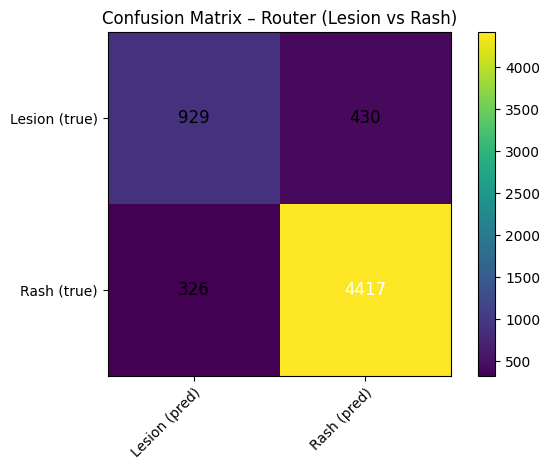

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# 1) Build 2x2 confusion matrix
# rows = true class, cols = predicted class
# classes: 0 = lesion, 1 = rash
cm = np.zeros((2, 2), dtype=int)
for t, p in zip(y_true, y_pred):
    cm[t, p] += 1

print("Confusion matrix (rows = true, cols = pred):")
print(cm)

# 2) Plot heatmap
fig, ax = plt.subplots()
im = ax.imshow(cm, interpolation="nearest")

# Add colorbar
plt.colorbar(im, ax=ax)

# Axis labels
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["Lesion (pred)", "Rash (pred)"])
ax.set_yticklabels(["Lesion (true)", "Rash (true)"])

# Rotate x-labels for readability
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

# Annotate each cell with the count
for i in range(2):
    for j in range(2):
        ax.text(
            j, i,
            str(cm[i, j]),
            ha="center", va="center",
            color="white" if cm[i, j] > cm.max() / 2 else "black",
            fontsize=12,
        )

ax.set_title("Confusion Matrix – Router (Lesion vs Rash)")
plt.tight_layout()
plt.show()


In [18]:
import numpy as np

thresholds = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.85, 0.90, 0.95, 0.98, 0.99]

def lesion_metrics_at_threshold(th):
    y_pred = (y_prob >= th).astype(int)
    tp = np.sum((y_true == 0) & (y_pred == 0))
    fn = np.sum((y_true == 0) & (y_pred == 1))
    fp = np.sum((y_true == 1) & (y_pred == 0))
    tn = np.sum((y_true == 1) & (y_pred == 1))
    rec = tp / (tp + fn + 1e-8)
    prec = tp / (tp + fp + 1e-8)
    acc = (tp + tn) / (tp + tn + fp + fn + 1e-8)
    return tp, fn, fp, tn, rec, prec, acc

print("Threshold  TP  FN  FP  TN   Rec_lesion  Prec_lesion  Acc_overall")
for th in thresholds:
    tp, fn, fp, tn, rec, prec, acc = lesion_metrics_at_threshold(th)
    print(f"{th:8.2f} {tp:4d} {fn:4d} {fp:4d} {tn:4d}   {rec:9.3f}    {prec:11.3f}   {acc:10.3f}")


Threshold  TP  FN  FP  TN   Rec_lesion  Prec_lesion  Acc_overall
    0.05  402  957   10 4733       0.296          0.976        0.842
    0.10  521  838   21 4722       0.383          0.961        0.859
    0.15  597  762   34 4709       0.439          0.946        0.870
    0.20  651  708   53 4690       0.479          0.925        0.875
    0.25  699  660   81 4662       0.514          0.896        0.879
    0.30  757  602  116 4627       0.557          0.867        0.882
    0.40  844  515  211 4532       0.621          0.800        0.881
    0.50  929  430  326 4417       0.684          0.740        0.876
    0.60 1027  332  497 4246       0.756          0.674        0.864
    0.70 1119  240  737 4006       0.823          0.603        0.840
    0.80 1199  160 1133 3610       0.882          0.514        0.788
    0.85 1244  115 1394 3349       0.915          0.472        0.753
    0.90 1300   59 1768 2975       0.957          0.424        0.701
    0.95 1340   19 2232 2511       0.9

Confusion matrix at threshold = 0.90 (rows = true, cols = pred):
          pred_lesion   pred_rash
true_lesion   1300           59
true_rash     1768         2975

Lesion metrics at thr=0.90:
  Recall (sens lesion):   0.957
  Precision (PPV lesion): 0.424
  Overall accuracy:       0.701


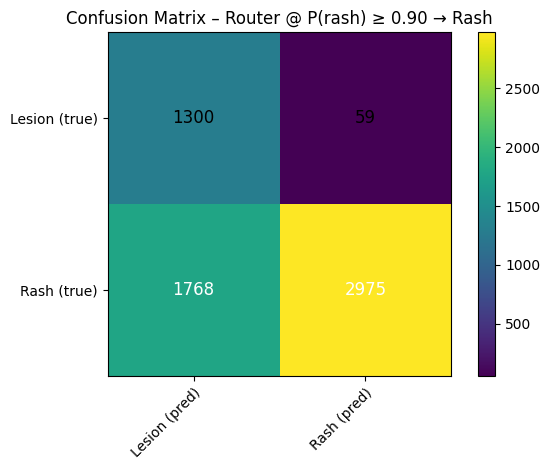

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------
# Threshold and predictions
# ---------------------------
thr = 0.90
y_pred_90 = (y_prob >= thr).astype(int)  # 1 = rash, 0 = lesion

# Build 2x2 confusion matrix: rows = true, cols = pred
cm_90 = np.zeros((2, 2), dtype=int)
for t, p in zip(y_true, y_pred_90):
    cm_90[t, p] += 1

print("Confusion matrix at threshold = 0.90 (rows = true, cols = pred):")
print("          pred_lesion   pred_rash")
print(f"true_lesion   {cm_90[0,0]:4d}         {cm_90[0,1]:4d}")
print(f"true_rash     {cm_90[1,0]:4d}         {cm_90[1,1]:4d}")

# Metrics for class 0 (lesion)
tp = cm_90[0, 0]
fn = cm_90[0, 1]
fp = cm_90[1, 0]
tn = cm_90[1, 1]

rec_lesion  = tp / (tp + fn + 1e-8)
prec_lesion = tp / (tp + fp + 1e-8)
acc_overall = (tp + tn) / (tp + tn + fp + fn + 1e-8)

print(f"\nLesion metrics at thr={thr:.2f}:")
print(f"  Recall (sens lesion):   {rec_lesion:.3f}")
print(f"  Precision (PPV lesion): {prec_lesion:.3f}")
print(f"  Overall accuracy:       {acc_overall:.3f}")

# ---------------------------
# Plot heatmap
# ---------------------------
fig, ax = plt.subplots()
im = ax.imshow(cm_90, interpolation="nearest")

plt.colorbar(im, ax=ax)

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["Lesion (pred)", "Rash (pred)"])
ax.set_yticklabels(["Lesion (true)", "Rash (true)"])

plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

# Annotate cells
for i in range(2):
    for j in range(2):
        count = cm_90[i, j]
        ax.text(
            j, i, str(count),
            ha="center", va="center",
            color="white" if count > cm_90.max() / 2 else "black",
            fontsize=12,
        )

ax.set_title("Confusion Matrix – Router @ P(rash) ≥ 0.90 → Rash")
plt.tight_layout()
plt.show()


In [20]:
import tensorflow as tf

artifacts_dir = data_root / "artifacts"

# Load best Stage 2 router
stage2_path = artifacts_dir / "router_mnv3_stage2_gpu.keras"
print("Loading Stage 2 router from:", stage2_path)
router_final = tf.keras.models.load_model(stage2_path)

# Save as final router with threshold 0.90
final_router_path = artifacts_dir / "router_mnv3_router_v1_thr090.keras"
router_final.save(final_router_path)

print("\nFinal Router model saved as:")
print(final_router_path)
print("\nRouting rule (to note in report/app):")
print("If P(rash) >= 0.90 → send to Rash specialist (Model 4)")
print("Else → send to Lesion specialist (Model 3)")


Loading Stage 2 router from: /workspaces/cmp9137-advanced-machine-learning/CMP9137 Advanced Machine Learning/skin-app/data/artifacts/router_mnv3_stage2_gpu.keras

Final Router model saved as:
/workspaces/cmp9137-advanced-machine-learning/CMP9137 Advanced Machine Learning/skin-app/data/artifacts/router_mnv3_router_v1_thr090.keras

Routing rule (to note in report/app):
If P(rash) >= 0.90 → send to Rash specialist (Model 4)
Else → send to Lesion specialist (Model 3)
